# Laboratory 5: High-Quality Edge Detection (Canny Method)

## Overview
The "Canny" method is one of the best ways to find edges in pictures. This laboratory breaks down the first three main steps of this method: cleaning the image with blur, finding the direction and strength of edges, and sharpening those edges so only the best ones remain.

## Topics Used
* **Gaussian Blur:** Using a math-based blur to remove "noise" (grainy dots) so we don't accidentally find "fake" edges.
* **Sobel Gradients:** Finding how much the color changes in both horizontal and vertical directions.
* **Gradient Magnitude:** Calculating the "strength" of an edge.
* **Gradient Orientation:** Figuring out which direction (angle) an edge is pointing.
* **Non-Maximum Suppression (NMS):** Thinning out the edges so they are only 1 pixel wide and very sharp.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to show images
def show_image(img, title='Image'):
    plt.figure(figsize=(8, 6))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

### Step 1: Loading the image
We load a grainy image of a face and convert it to grayscale.

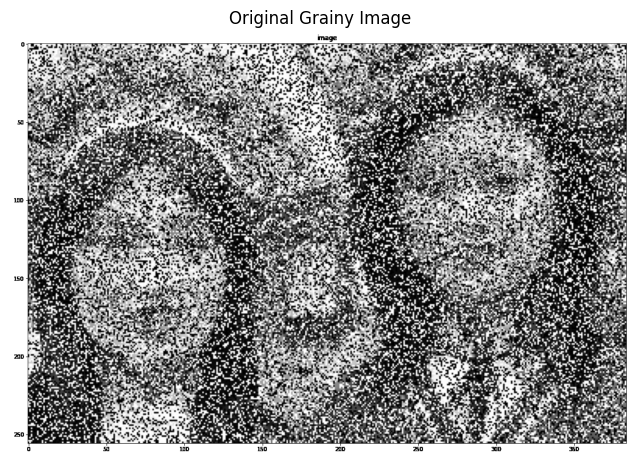

In [2]:
img = cv2.imread("face_noise.png", cv2.IMREAD_GRAYSCALE)
show_image(img, 'Original Grainy Image')

### Step 2: Smoothing (Gaussian Blur)
We use a 5x5 Gaussian blur to smooth the image. This helps remove the noise so it doesn't look like an edge to the computer.

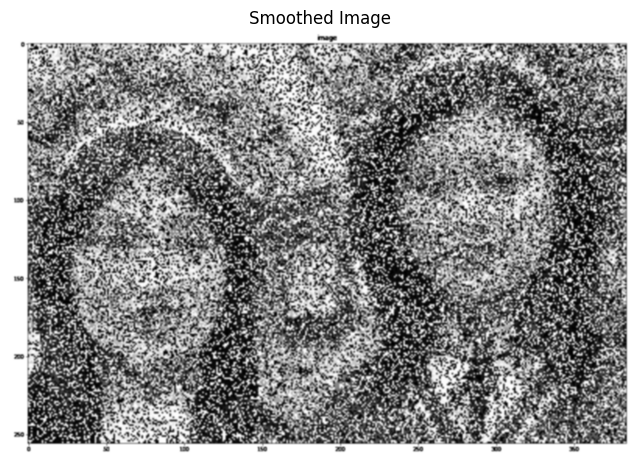

In [3]:
blur = cv2.GaussianBlur(img, (5, 5), 1.4)
show_image(blur, 'Smoothed Image')

### Step 3: Finding Edges (Sobel)
We calculate the horizontal (`s_x`) and vertical (`s_y`) change. Then we combine them to find the total edge strength (`mag`) and the angle of the edge (`ang`).

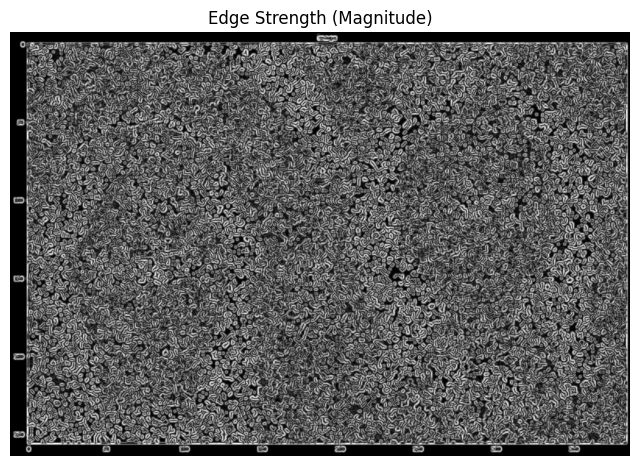

In [4]:
s_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
s_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

# Magnitude is the 'total' brightness of the edge
mag = np.sqrt(s_x*s_x + s_y*s_y)
mag = (mag / mag.max()) * 255
mag = mag.astype(np.uint8)

# Angle tells us where the edge is pointing
ang = np.arctan2(s_y, s_x) * 180 / np.pi
ang[ang < 0] += 180

show_image(mag, 'Edge Strength (Magnitude)')

### Step 4: Sharpening (Non-Maximum Suppression)
This is the tricky part! We look at each pixel and check its neighbors along the direction of the edge. If the current pixel isn't the "strongest" (maximum) compared to its neighbors, we throw it away (suppress it). This makes the edges look very thin and precise.

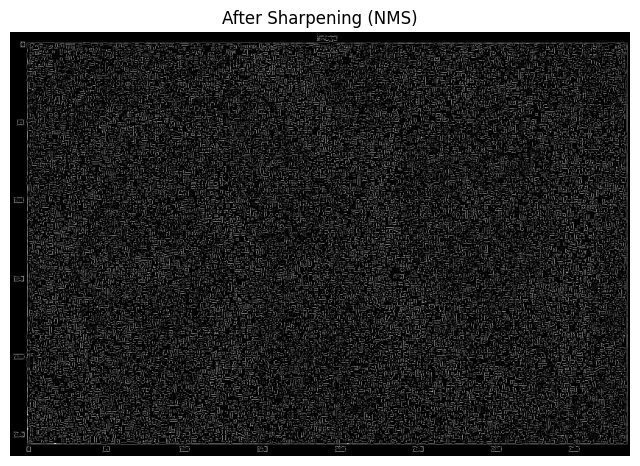

True

In [5]:
h, w = mag.shape
out = np.zeros((h, w), dtype=np.uint8)

for i in range(1, h-1):
    for j in range(1, w-1):
        # We fix how we store the angle and magnitude values
        a = ang[i, j]
        m = mag[i, j]
        
        q = 255
        r = 255

        # Pick neighbors based on the angle
        if (0 <= a < 22.5) or (157.5 <= a <= 180): 
            q, r = mag[i, j+1], mag[i, j-1]
        elif 22.5 <= a < 67.5:                     
            q, r = mag[i+1, j-1], mag[i-1, j+1]
        elif 67.5 <= a < 112.5:                    
            q, r = mag[i+1, j], mag[i-1, j]
        else:                                      
            q, r = mag[i-1, j-1], mag[i+1, j+1]

        # Only keep the pixel if it's the strongest in its local area
        if (m >= q) and (m >= r):
            out[i, j] = m
        else:
            out[i, j] = 0

show_image(out, 'After Sharpening (NMS)')
cv2.imwrite("saved_image.png", out)